In [1]:
"""
Practical usage examples for measured.py and summary_plot.py.

All examples assume a RangeScene has been configured and that
measured DataFrames contain the required columns:
    tdb, rh, tr, vr, met, clo, wme
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pythermalcomfort.models import pmv_ppd_iso

from range_scene import RangeScene
from measured import summary, compute_pmv, categorize_pmv, overlay_scatter, LayoutConfig
from summary_plot import SummaryPlot

In [2]:
# ── Shared setup ────────────────────────────────────────────

scene = RangeScene(pmv_ppd_iso)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters(vr=0.1, met=1.2, clo=0.5, wme=0)

BINS = [float("-inf"), -0.5, 0.5, float("inf")]
LABELS = ["Cold", "Neutral", "Hot"]
COLORS = ["#4c78a8", "#d9d9d9", "#c9415f"]

In [3]:
# ── Sample measured data ────────────────────────────────────
# Simulates indoor sensor readings across seasons.

rng = np.random.default_rng(42)

def make_measured(n: int, tdb_mean: float, tdb_std: float, rh_mean: float) -> pd.DataFrame:
    """Generate a synthetic measured DataFrame."""
    tdb = rng.normal(tdb_mean, tdb_std, n).clip(10, 40)
    return pd.DataFrame({
        "tdb": tdb,
        "rh":  rng.normal(rh_mean, 8, n).clip(10, 95),
        "tr":  tdb + rng.normal(0, 0.5, n),   # tr ≈ tdb with small offset
        "vr":  np.full(n, 0.1),
        "met": np.full(n, 1.2),
        "clo": np.full(n, 0.5),
        "wme": np.full(n, 0.0),
    })

df_summer = make_measured(n=200, tdb_mean=28, tdb_std=3, rh_mean=65)
df_winter = make_measured(n=200, tdb_mean=18, tdb_std=3, rh_mean=40)
df_annual = pd.concat([df_summer, df_winter], ignore_index=True)

# Pre-compute PMV for examples that need it
df_summer_pmv = compute_pmv(df_summer)
df_winter_pmv = compute_pmv(df_winter)
df_annual_pmv = compute_pmv(df_annual)

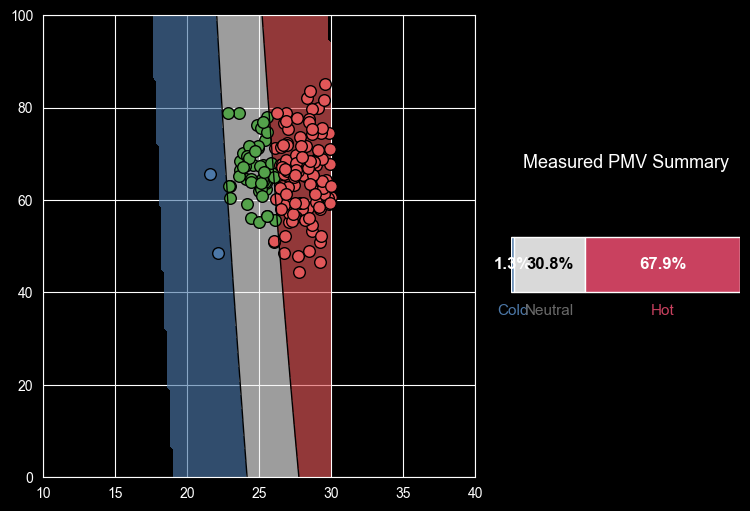

In [4]:
# ================================================================
#  Example 1 — Single image + Auto right panel
# ================================================================

base_plot = scene.plot_contour(output="pmv", levels=[-0.5, 0.5])

result = summary(df_summer, base_plot)

plt.show()

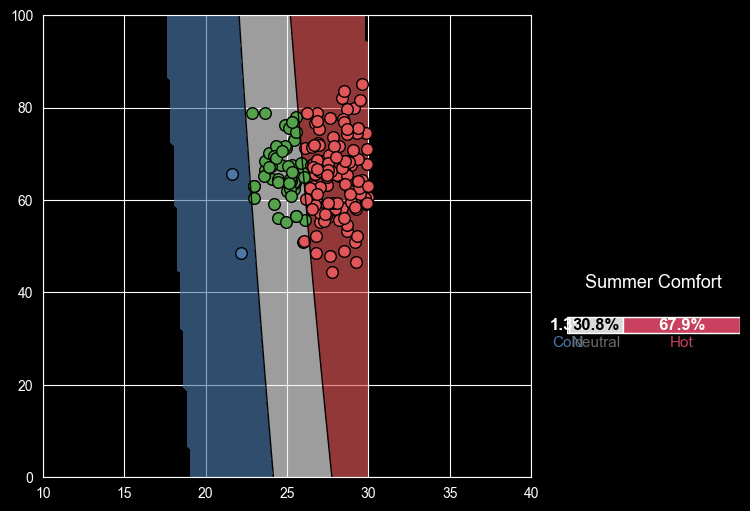

In [5]:
# ================================================================
#  Example 2 — Single image + custom layout ratio
# ================================================================

compact = LayoutConfig(left_ratio=0.70, panel_height_ratio=0.10)

base_plot = scene.plot_contour(output="pmv", levels=[-0.5, 0.5])

result = summary(
    df_summer, base_plot,
    layout=compact,
    summary_title="Summer Comfort",
)
plt.show()

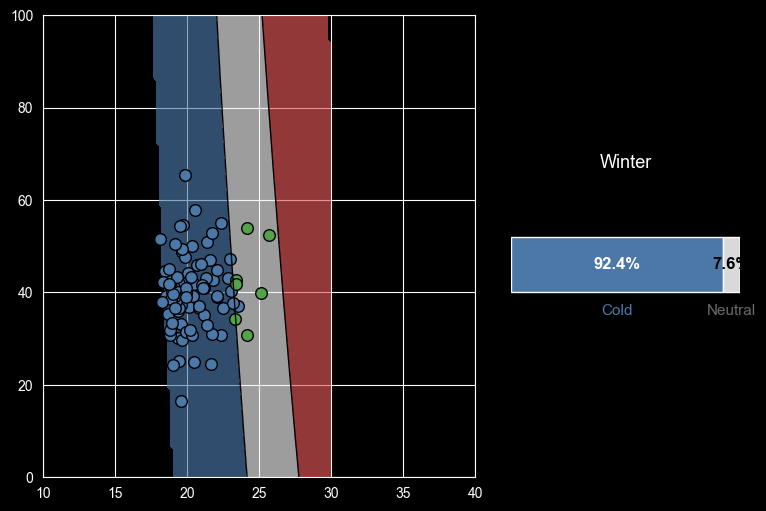

In [6]:
# ================================================================
#  Example 3 — Replace Overlay (Switch Datasets on the Same Base Plot)
# ================================================================

base_plot = scene.plot_contour(output="pmv", levels=[-0.5, 0.5])

r1 = summary(df_summer, base_plot, summary_title="Summer")

r2 = summary(df_winter, base_plot, previous=r1, summary_title="Winter")
plt.show()

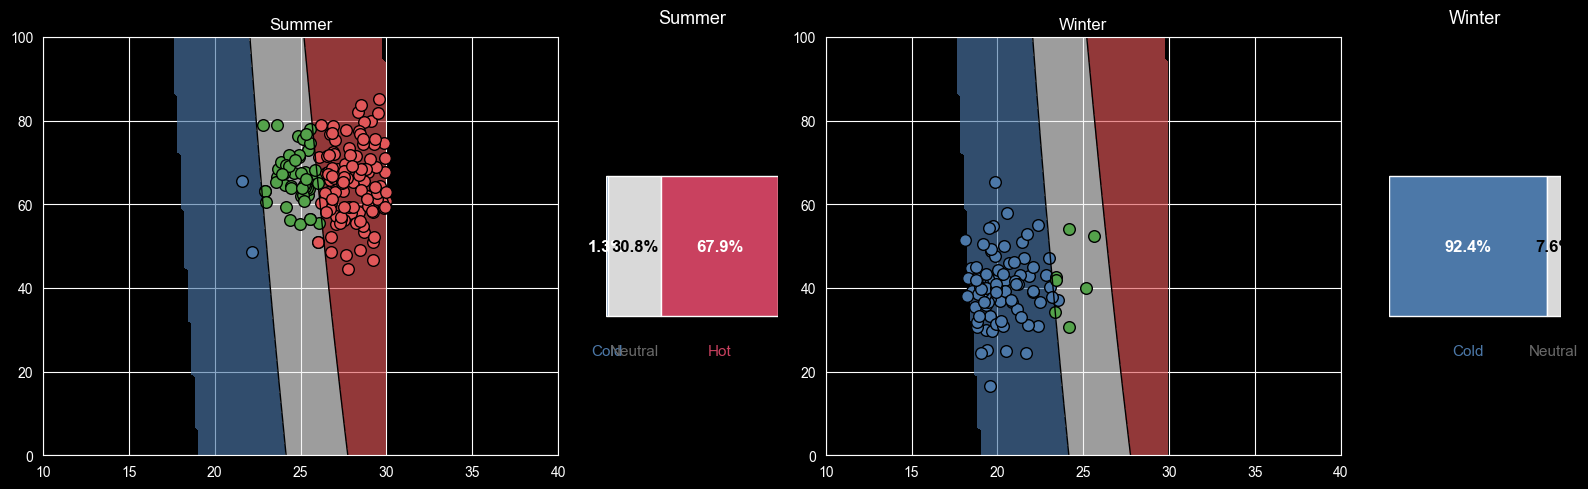

In [7]:
# ================================================================
#  Example 4 — Two images side-by-side + each with its own independent panel (seasonal comparison)
# ================================================================

fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    gridspec_kw={"width_ratios": [3, 1, 3, 1]},
)

plot_summer = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=axes[0])
plot_winter = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=axes[2])

axes[0].set_title("Summer")
axes[2].set_title("Winter")

r_summer = summary(df_summer, plot_summer, ax_right=axes[1], summary_title="Summer")
r_winter = summary(df_winter, plot_winter, ax_right=axes[3], summary_title="Winter")

plt.tight_layout()
plt.show()

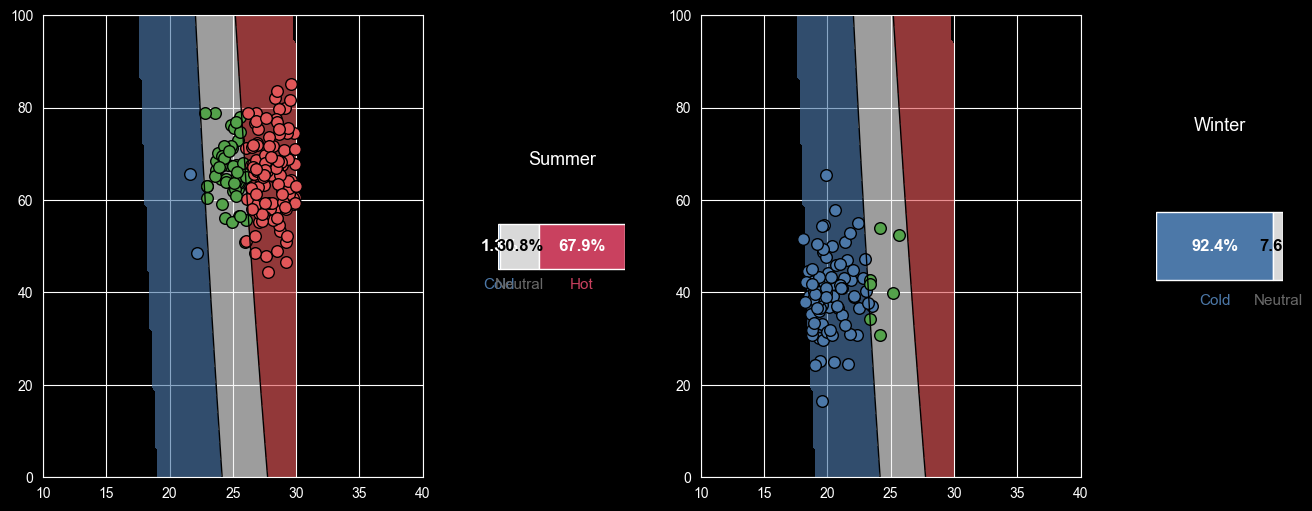

In [8]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(16, 6))

outer = GridSpec(1, 4, figure=fig, width_ratios=[3, 1, 3, 1], wspace=0.3)

inner_panel1 = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer[1],
    height_ratios=[1, 1, 1],
)

inner_panel2 = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer[3],
    height_ratios=[1, 2, 1],
)

ax_main1  = fig.add_subplot(outer[0])
ax_panel1 = fig.add_subplot(inner_panel1[1])

ax_main2  = fig.add_subplot(outer[2])
ax_panel2 = fig.add_subplot(inner_panel2[1])

plot1 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=ax_main1)
plot2 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=ax_main2)

r1 = summary(df_summer, plot1, ax_right=ax_panel1, summary_title="Summer")
r2 = summary(df_winter, plot2, ax_right=ax_panel2, summary_title="Winter")

plt.show()

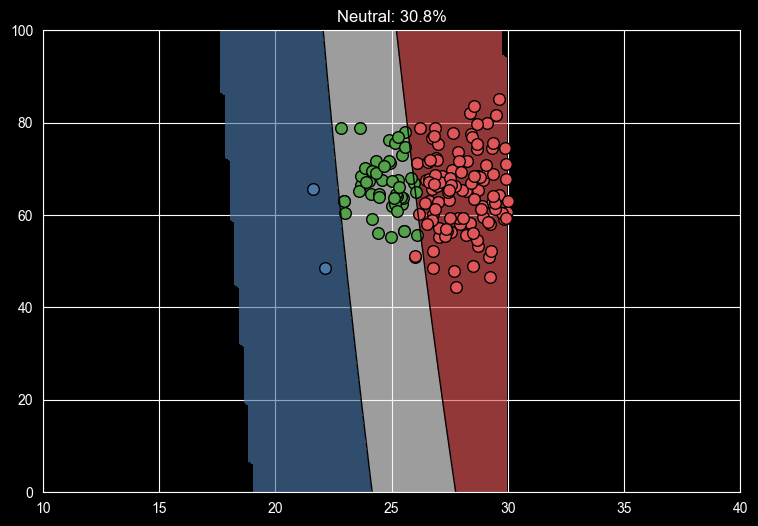

In [9]:
# ================================================================
#  Example 5 — Scatter plot only, no summary
# ================================================================

fig, ax = plt.subplots(figsize=(9, 6))
base_plot = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=ax)

df_out = compute_pmv(df_summer)
df_out, pct = categorize_pmv(df_out)
artists = overlay_scatter(ax, df_out, LABELS)

ax.set_title(f"Neutral: {pct['Neutral']:.1f}%")
plt.show()

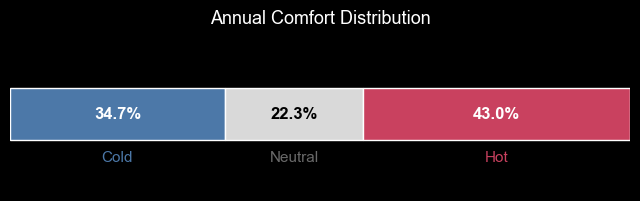

In [10]:
# ================================================================
#  Example 6 — Independent SummaryPlot (not dependent on RangeScene)
# ================================================================

sp = SummaryPlot(
    df_annual_pmv,
    target_column="pmv",
    bins=BINS,
    labels=LABELS,
    colors=COLORS,
)
result = sp.plot(title="Annual Comfort Distribution")
plt.show()

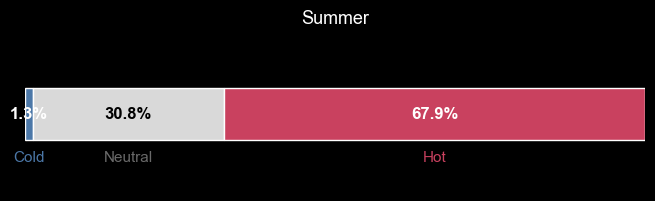

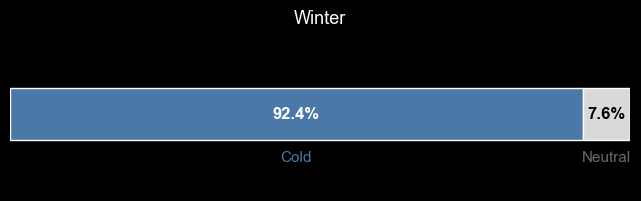

In [11]:
# ================================================================
#  Example 7 — switching data on the same panel
# ================================================================


sp = SummaryPlot(
    df_summer_pmv,
    target_column="pmv",
    bins=BINS,
    labels=LABELS,
    colors=COLORS,
)

fig1, ax1 = plt.subplots(figsize=(8, 2))
sp.plot(ax=ax1, title="Summer")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 2))
sp.update(df_winter_pmv).plot(ax=ax2, title="Winter")
plt.show()

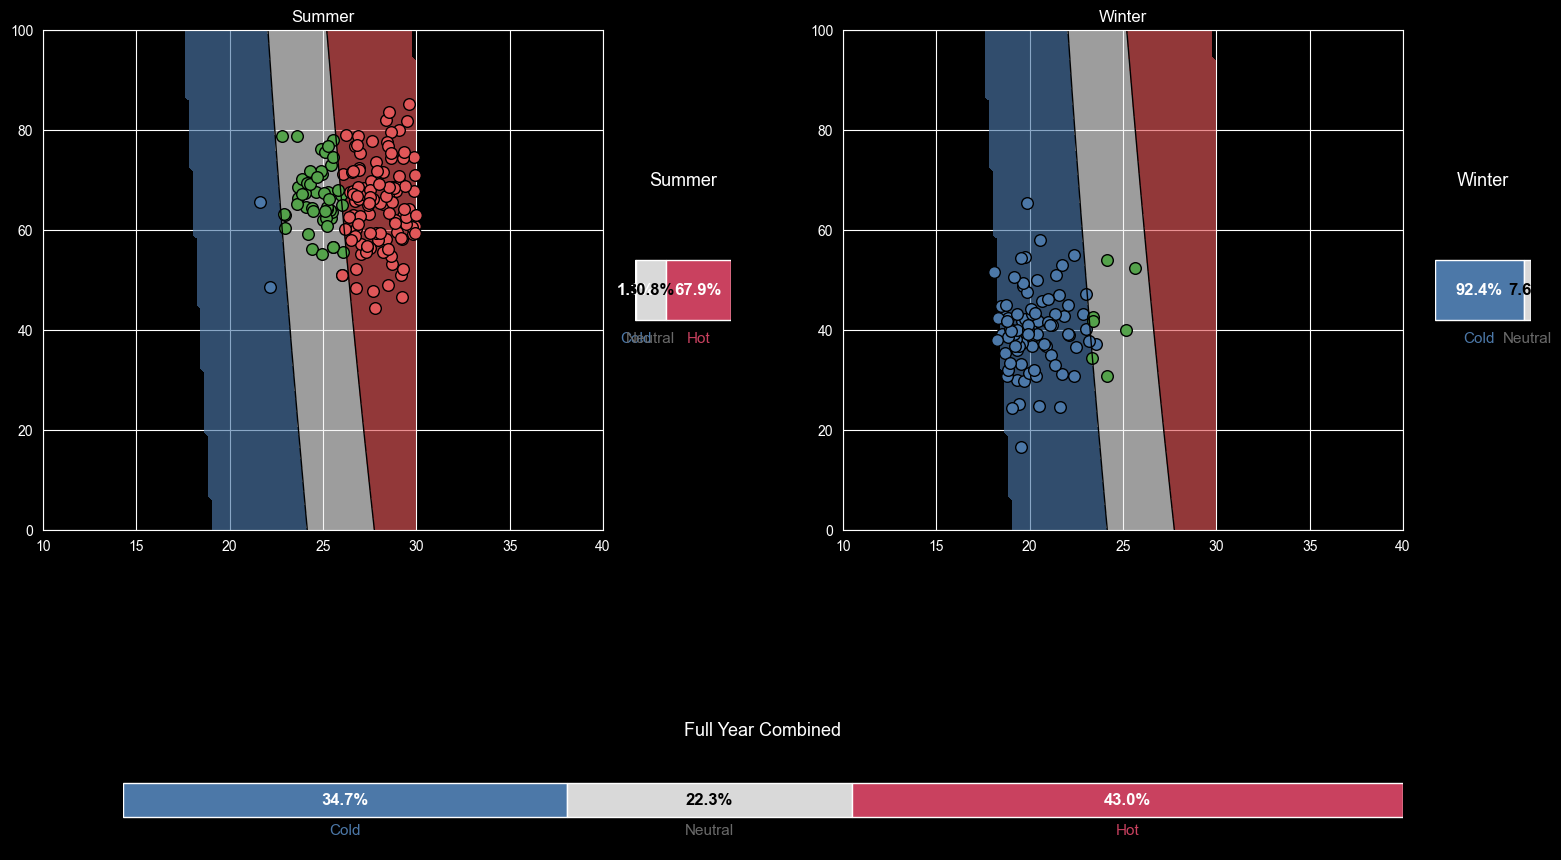

In [12]:
# ================================================================
#  Example 8 — Shared Summary
# ================================================================

fig = plt.figure(figsize=(16, 10))

ax1    = fig.add_axes([0.05, 0.40, 0.35, 0.50])
panel1 = fig.add_axes([0.42, 0.55, 0.06, 0.18])
ax2    = fig.add_axes([0.55, 0.40, 0.35, 0.50])
panel2 = fig.add_axes([0.92, 0.55, 0.06, 0.18])

ax_bar = fig.add_axes([0.10, 0.08, 0.80, 0.10])

plot1 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=ax1)
plot2 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=ax2)

ax1.set_title("Summer")
ax2.set_title("Winter")

r1 = summary(df_summer, plot1, ax_right=panel1, summary_title="Summer")
r2 = summary(df_winter, plot2, ax_right=panel2, summary_title="Winter")

combined_df = pd.concat([r1.data, r2.data], ignore_index=True)
SummaryPlot(combined_df, target_column="pmv",
            bins=BINS, labels=LABELS, colors=COLORS).plot(
    ax=ax_bar,
    title="Full Year Combined",
)

plt.show()

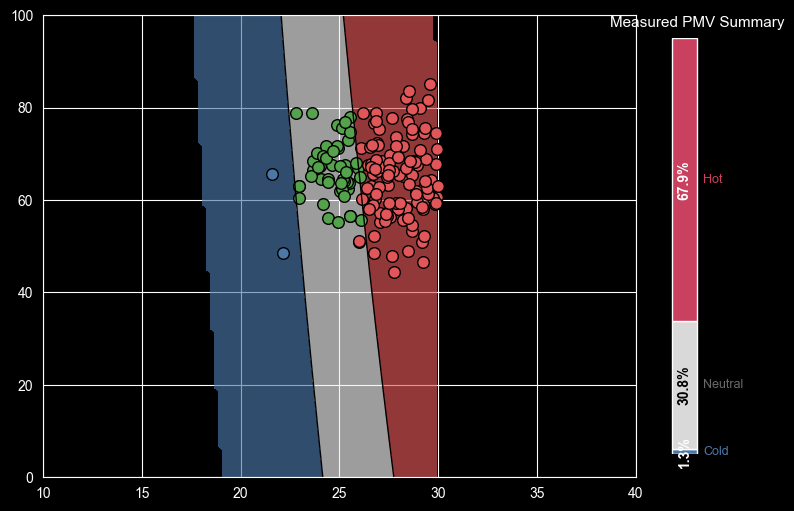

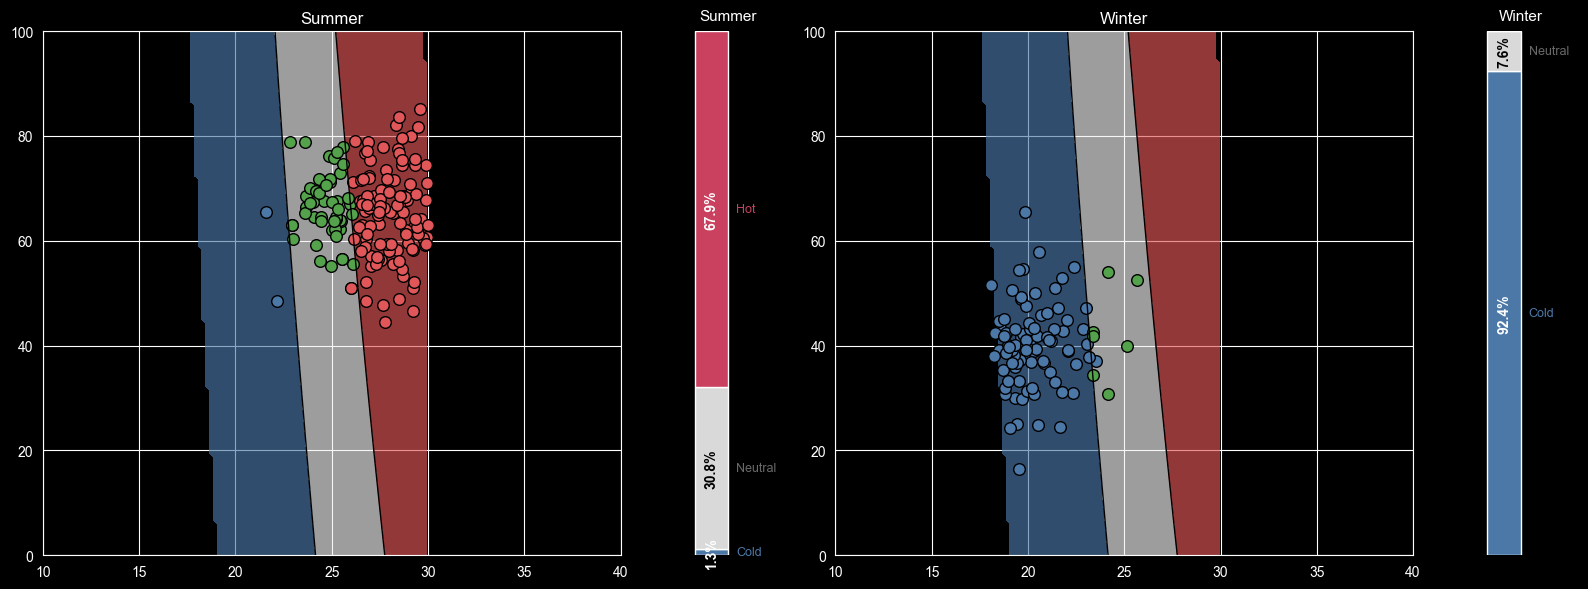

In [14]:
# ================================================================
#  vertical
# ================================================================

base_plot = scene.plot_contour(output="pmv", levels=[-0.5, 0.5])

result = summary(df_summer, base_plot, orientation="vertical")
plt.show()

fig, axes = plt.subplots(
    1, 4, figsize=(16, 6),
    gridspec_kw={"width_ratios": [5, 1, 5, 1]},
)

plot1 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=axes[0])
plot2 = scene.plot_contour(output="pmv", levels=[-0.5, 0.5], ax=axes[2])

axes[0].set_title("Summer")
axes[2].set_title("Winter")

r1 = summary(df_summer, plot1, ax_right=axes[1],
             summary_title="Summer", orientation="vertical")
r2 = summary(df_winter, plot2, ax_right=axes[3],
             summary_title="Winter", orientation="vertical")

plt.tight_layout()
plt.show()